In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Load data
X_train = np.load('../data/processed/X_train.npy')
y_train = np.load('../data/processed/y_train.npy')

X_val = np.load("../data/processed/X_val.npy")
y_val = np.load("../data/processed/y_val.npy")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)


X_train shape: (69600, 128, 128, 3)
y_train shape: (69600, 29)
X_val shape: (17400, 128, 128, 3)
y_val shape: (17400, 29)


In [3]:
#check data range
print("Min pixel value:", X_train.min())
print("Max pixel value:", X_train.max())

Min pixel value: -1.0
Max pixel value: 1.0


In [4]:
#check label format
print("Unique labels:", np.unique(y_train))
print("Number of classes:", len(np.unique(y_train)))

Unique labels: [0. 1.]
Number of classes: 2


In [5]:
print("y_train sample:", y_train[0])

y_train sample: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.]


In [6]:
y_train = np.argmax(y_train, axis=1)
y_val = np.argmax(y_val, axis=1)

In [7]:
print("Unique labels:", np.unique(y_train))
print("Number of classes:", len(np.unique(y_train)))

Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28]
Number of classes: 29


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

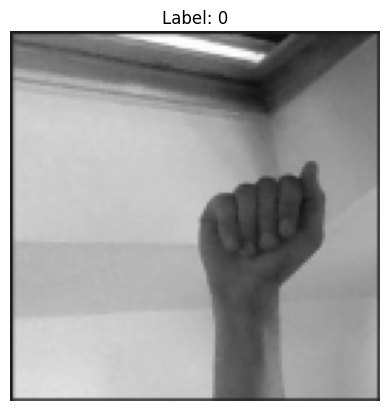

In [8]:
plt.imshow((X_train[0] + 1) / 2)  # convert back to [0,1] for display
plt.title(f"Label: {y_train[0]}")
plt.axis("off")

In [9]:
import torch
print(torch.cuda.get_arch_list()) # Look for 'sm_120'
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

['sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']
Torch version: 2.12.0.dev20260408+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


In [10]:
X_train = torch.tensor(X_train).permute(0, 3, 1, 2).float()
X_val = torch.tensor(X_val).permute(0, 3, 1, 2).float()

y_train = torch.tensor(y_train).long()
y_val = torch.tensor(y_val).long()

print("X_train shape:", X_train.shape)

X_train shape: torch.Size([69600, 3, 128, 128])


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Load MobileNetV2

In [13]:
from torchvision import models
import torch.nn as nn

model = models.mobilenet_v2(pretrained=True)

d:\Edu\3rd Year\2nd Sem\Deep Learning\Real-time-Sign-Language-to-Text-Conversion\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Edu\3rd Year\2nd Sem\Deep Learning\Real-time-Sign-Language-to-Text-Conversion\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Modify Final Layer

In [14]:
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 29)

### Freeze Feature Extractor

In [15]:
for param in model.features.parameters():
    param.requires_grad = False

### Move Model to Device

In [16]:
model = model.to(device)

### Verify Model

In [17]:
print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=29, bias=True)
)


### Check Trainable Parameters

In [18]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print("Trainable params:", trainable)
print("Total params:", total)

Trainable params: 37149
Total params: 2261021


### Create DataLoader

In [19]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

### Loss Function

In [20]:
criterion = nn.CrossEntropyLoss()

### Optimizer

In [21]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.001)

### Training Loop

In [22]:
import time

num_epochs = 20

# Early stopping settings
patience = 3
counter = 0
best_val_loss = float('inf')
best_val_acc = 0

# History tracking
train_losses_1 = []
val_losses_1 = []
train_accs_1 = []
val_accs_1 = []

for epoch in range(num_epochs):
    start_time = time.time()

    # ================= TRAIN =================
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total
    avg_train_loss = train_loss / len(train_loader)
    
    train_losses_1.append(avg_train_loss)
    train_accs_1.append(train_acc)

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    avg_val_loss = val_loss / len(val_loader)

    val_losses_1.append(avg_val_loss)
    val_accs_1.append(val_acc)

    # ================= LOGGING =================
    duration = time.time() - start_time

    print(f"\nEpoch {epoch+1} Summary:")
    print(f" Train: Loss={avg_train_loss:.4f}, Acc={train_acc*100:.2f}%")
    print(f" Val:   Loss={avg_val_loss:.4f}, Acc={val_acc*100:.2f}%")
    print(f" Time:  {duration:.1f}s")

    # ================= SAVE BEST MODEL (ACCURACY) =================
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        print(f" >> New best validation accuracy: {val_acc*100:.2f}%")

    # ================= EARLY STOPPING (LOSS) =================
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        print(" >> Validation loss improved, saving model")

        torch.save(model.state_dict(), "best_model.pth")

    else:
        counter += 1
        print(f" >> No improvement ({counter}/{patience})")

        if counter >= patience:
            print("\n Early stopping triggered!")
            break

    print("-" * 60)


Epoch 1 Summary:
 Train: Loss=0.7153, Acc=79.82%
 Val:   Loss=0.2845, Acc=92.02%
 Time:  53.4s
 >> New best validation accuracy: 92.02%
 >> Validation loss improved, saving model
------------------------------------------------------------

Epoch 2 Summary:
 Train: Loss=0.4069, Acc=87.01%
 Val:   Loss=0.1942, Acc=94.33%
 Time:  38.8s
 >> New best validation accuracy: 94.33%
 >> Validation loss improved, saving model
------------------------------------------------------------

Epoch 3 Summary:
 Train: Loss=0.3660, Acc=88.11%
 Val:   Loss=0.1829, Acc=94.25%
 Time:  44.1s
 >> Validation loss improved, saving model
------------------------------------------------------------

Epoch 4 Summary:
 Train: Loss=0.3414, Acc=88.89%
 Val:   Loss=0.1582, Acc=94.98%
 Time:  33.7s
 >> New best validation accuracy: 94.98%
 >> Validation loss improved, saving model
------------------------------------------------------------

Epoch 5 Summary:
 Train: Loss=0.3395, Acc=88.79%
 Val:   Loss=0.1446, Acc=95

### Unfreeze last layers

In [23]:
# Unfreeze last few layers of feature extractor
for param in model.features[-4:].parameters():
    param.requires_grad = True

In [24]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print("Trainable params after unfreezing:", trainable)
print("Total params:", total)

Trainable params after unfreezing: 1563229
Total params: 2261021


### Using smaller learning rate

In [25]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [26]:
criterion = torch.nn.CrossEntropyLoss()

### Training with fewer epochs(smaller learning rate)

In [27]:
num_epochs = 15  

patience = 3
counter = 0
best_val_loss = float('inf')
best_val_acc = 0

# History tracking
train_losses_2 = []
val_losses_2 = []
train_accs_2 = []
val_accs_2 = []

for epoch in range(num_epochs):
    start_time = time.time()

    # ================= TRAIN =================
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total
    avg_train_loss = train_loss / len(train_loader)
    
    train_losses_2.append(avg_train_loss)
    train_accs_2.append(train_acc)

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    avg_val_loss = val_loss / len(val_loader)

    val_losses_2.append(avg_val_loss)
    val_accs_2.append(val_acc)

    # ================= LOGGING =================
    duration = time.time() - start_time

    print(f"\n[Fine-Tune] Epoch {epoch+1} Summary:")
    print(f" Train: Loss={avg_train_loss:.4f}, Acc={train_acc*100:.2f}%")
    print(f" Val:   Loss={avg_val_loss:.4f}, Acc={val_acc*100:.2f}%")
    print(f" Time:  {duration:.1f}s")

    # Track best accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        print(f" >> New best validation accuracy: {val_acc*100:.2f}%")

    # Early stopping (based on loss)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        print(" >> Validation loss improved, saving model")

        torch.save(model.state_dict(), "best_model_finetuned.pth")

    else:
        counter += 1
        print(f" >> No improvement ({counter}/{patience})")

        if counter >= patience:
            print("\n Early stopping triggered!")
            break

    print("-" * 60)


[Fine-Tune] Epoch 1 Summary:
 Train: Loss=0.1385, Acc=95.69%
 Val:   Loss=0.0282, Acc=99.00%
 Time:  46.1s
 >> New best validation accuracy: 99.00%
 >> Validation loss improved, saving model
------------------------------------------------------------

[Fine-Tune] Epoch 2 Summary:
 Train: Loss=0.0476, Acc=98.48%
 Val:   Loss=0.0152, Acc=99.51%
 Time:  39.0s
 >> New best validation accuracy: 99.51%
 >> Validation loss improved, saving model
------------------------------------------------------------

[Fine-Tune] Epoch 3 Summary:
 Train: Loss=0.0386, Acc=98.84%
 Val:   Loss=0.0088, Acc=99.70%
 Time:  51.0s
 >> New best validation accuracy: 99.70%
 >> Validation loss improved, saving model
------------------------------------------------------------

[Fine-Tune] Epoch 4 Summary:
 Train: Loss=0.0301, Acc=99.17%
 Val:   Loss=0.0104, Acc=99.67%
 Time:  46.4s
 >> No improvement (1/3)
------------------------------------------------------------

[Fine-Tune] Epoch 5 Summary:
 Train: Loss=0.02

### Visualize graphs

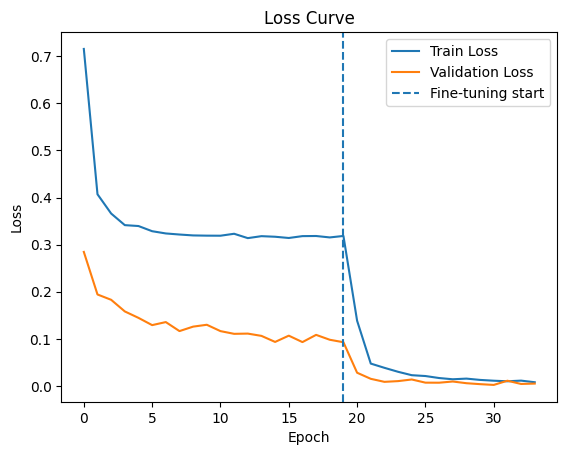

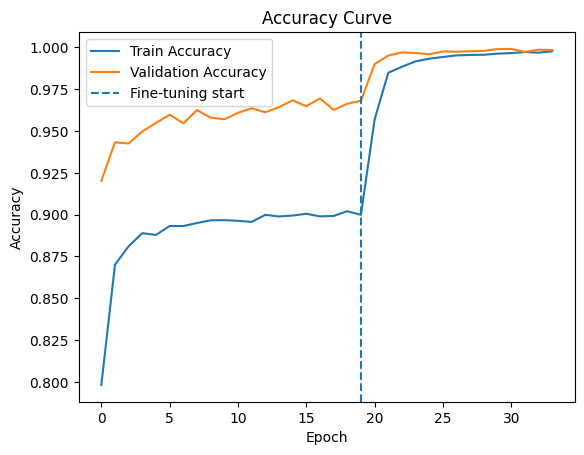

In [28]:
train_losses = train_losses_1 + train_losses_2
val_losses = val_losses_1 + val_losses_2
train_accs = train_accs_1 + train_accs_2
val_accs = val_accs_1 + val_accs_2

# Loss
plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.axvline(x=len(train_losses_1)-1, linestyle='--', label='Fine-tuning start')
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Accuracy
plt.figure()
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.axvline(x=len(train_accs_1)-1, linestyle='--', label='Fine-tuning start')
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()